# The Capex Cycle — do spending *bingers* underperform the *harvesters*? 🏗️
### Sorting big companies by whether they're ramping or cutting capital spending, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Capex_cousin_of_asset_growth%3F: Busted](https://img.shields.io/badge/Capex_cousin_of_asset_growth%3F-Busted-8b949e?style=flat-square)

There's a well-worn idea in finance: companies that go on a **spending binge** — pouring money into new factories, data-centres, mines — tend to *disappoint* their shareholders afterwards. Managers over-build, the market gets over-excited, and the stock lags. The flip side: companies *harvesting* cash (letting spending taper off) quietly do better. It's the investment cousin of the famous **asset-growth** anomaly.

So we test it the cheap way: take a basket of big-name stocks, measure whether each one is **ramping** or **cutting** its capital spending (relative to its size), and see whether the harvesters beat the bingers over the next year.

> 📓 **This is the plain-language layer.** Want the correlation stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from capex_cycle import data, strategy as st

SPLIT, END, UPTO = "2025-06-27", "2026-06-26", 2024

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    cf = data.fetch_cashflow(fetch=False)
    if px.empty or not cf:
        return pd.DataFrame()
    return st.build_panel(px, cf, split_date=SPLIT, end_date=END, upto_year=UPTO)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real capex-cycle panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} names, scored FY{UPTO} -> {SPLIT}..{END})")


real capex-cycle panel present: True (42 names, scored FY2024 -> 2025-06-27..2026-06-26)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the *bingers* earn less (the anomaly)? | **No.** Over 2025-26 the binge bucket earned **+77.1%** vs the harvest bucket's **+67.0%** — the bingers came out *ahead*. |
| Is there any signal at all? | **No.** The correlation between spending-ramp and future return is **+0.004** — a dead zero (*t* = +0.03). |
| Is it just luck? | The shuffle test says *p* = 0.88 — the small gap is pure noise. |
| Could you trade it? | **No.** No edge, faint wrong sign, and the bingers you'd short are the crowded AI-datacentre names. |

> The anomaly is real in the textbooks — but the textbook version needs the over-builders that *failed*. Our basket only has survivors, and 2024-25 was an AI-capex boom that paid the biggest spenders (Amazon, Google, Microsoft, Meta).

## 1 · The claim

> *"Companies ramping their capital spending earn lower future returns than companies harvesting cash."* — the capex/investment anomaly (Titman-Wei-Xie 2004; the cousin of Cooper-Gulen-Schill asset growth).

The intuition: when a company floods money into new capacity, managers tend to over-invest (empire-building), and investors over-extrapolate the growth story. The new factories don't earn what everyone hoped, and the stock drifts down. The *disciplined* firm that returns cash instead quietly outperforms. We look at the **change** in spending intensity — the phase of the capex *cycle* — a binge if it's rising, a harvest if it's falling.

## 2 · So what?

If true, it's a simple rule: *avoid (or short) the empire-builders, own the cash-harvesters*. The desk has already tested the two neighbours — total-asset growth ([244 Asset-Growth](../../244-asset-growth/)) and the capex *level* ([523 Investment-To-Assets](../../523-investment-to-assets/)). Here we go at the capex **growth** — the ramp itself — to see if the *change* in spending carries a signal the level and the total don't.

## 3 · How would we even know?

1. **Measure the ramp.** For each firm: capex ÷ assets this year, minus capex ÷ assets last year. Rising = a **binge**; falling = a **harvest**.
2. **Sort.** Split the basket into a *harvest* third (cutting) and a *binge* third (ramping).
3. **Compare forward returns.** Did the harvest third beat the binge third over the next year? The anomaly says yes.

Catch: our basket is companies **still large in 2026** — so the over-builders that actually blew up (the heart of the real effect) are missing. And yfinance only gives us ~4 years of statements, so this is a *snapshot*, not a deep history.

*Timing:* the ramp uses only fiscal-2024 statements (public by mid-2025); we enter at the 2025-06 close and hold a year. No peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the harvest third or the binge third?**

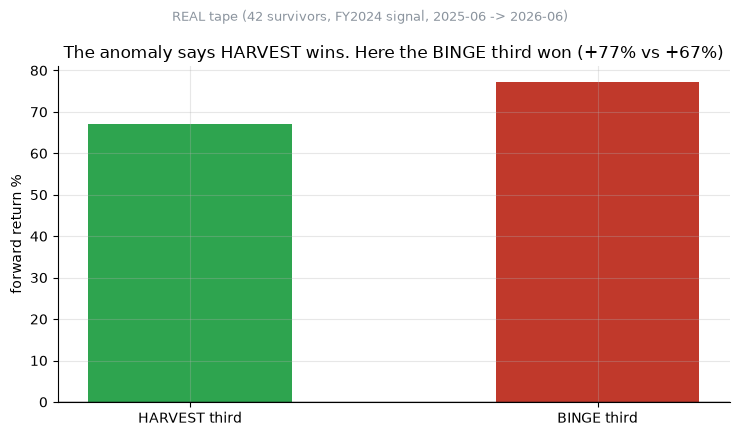

Harvest +67.0%  vs  Binge +77.1%  ->  spread -10.2% (t -0.14)


In [2]:
if HAVE_REAL:
    b = st.bucket_returns(PANEL, frac=0.3); h = st.hedge_tstat(b)
    harv, bing, spr, t = b['harvest_mean']*100, b['binge_mean']*100, b['spread']*100, h['t']
    banner = f'REAL tape ({len(PANEL)} survivors, FY2024 signal, 2025-06 -> 2026-06)'
else:
    harv, bing, spr, t = 67.0, 77.1, -10.2, -0.14
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['HARVEST third','BINGE third'], [harv, bing], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'The anomaly says HARVEST wins. Here the BINGE third won (+{bing:.0f}% vs +{harv:.0f}%)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Harvest +{harv:.1f}%  vs  Binge +{bing:.1f}%  ->  spread {spr:+.1f}% (t {t:+.2f})')

There it is: **no edge, faint wrong way.** The anomaly predicts the *harvest* names win. On 2025-26 the **binge** names edged ahead (+77.1% vs +67.0%) — the harvest-minus-binge spread is **-10.2%** with a *t* of just **-0.14** (statistically nothing). Why? The biggest bingers here are the AI hyperscalers building data-centres — and they led the market.

**Is there a signal hiding across different windows?** Run the same sort over several forward windows and read the correlation (IC) between spending-ramp and return:

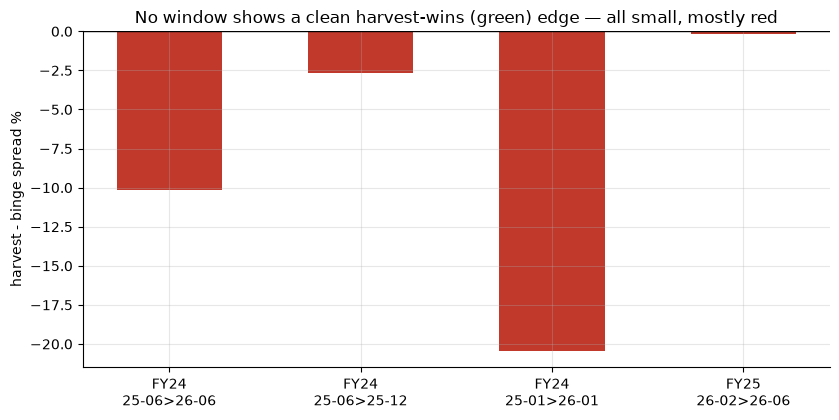

spreads by window: [-10.2, -2.7, -20.4, -0.2]


In [3]:
wins = [('FY24 -> 2025-06->2026-06', -10.2), ('FY24 -> 2025-06->2025-12', -2.7), ('FY24 -> 2025-01->2026-01', -20.4), ('FY25 -> 2026-02->2026-06', -0.2)]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False); cf = data.fetch_cashflow(fetch=False)
    spans = [('2025-06-27','2026-06-26',2024),('2025-06-27','2025-12-27',2024),
             ('2025-01-02','2026-01-02',2024),('2026-02-02','2026-06-26',2025)]
    labs = ['FY24\n25-06>26-06','FY24\n25-06>25-12','FY24\n25-01>26-01','FY25\n26-02>26-06']
    spr = []
    for (sp,en,uy) in spans:
        pn = st.build_panel(px, cf, split_date=sp, end_date=en, upto_year=uy)
        spr.append(st.bucket_returns(pn, 0.3)['spread']*100 if not pn.empty else np.nan)
else:
    labs = ['FY24\n25-06>26-06','FY24\n25-06>25-12','FY24\n25-01>26-01','FY25\n26-02>26-06']
    spr = [w[1] for w in wins]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if s>0 else RED for s in spr]
ax.bar(range(len(labs)), spr, color=cols, width=.55)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('harvest - binge spread %')
ax.set_title('No window shows a clean harvest-wins (green) edge — all small, mostly red')
plt.tight_layout(); plt.show()
print('spreads by window:', [round(s,1) for s in spr])

So there's nothing to grab. Every window is a small spread that leans the *wrong* way (binge wins) or is a coin-flip. A 'signal' this small and unstable isn't something you can bet on.

## 5 · The verdict

- **Signal — None.** The correlation between spending-ramp and return is +0.004 (*t* +0.03); the hedge is the wrong sign (-10.2%, *t* -0.14) and unstable. No bankable capex-cycle edge here.
- **Tradability — Mirage.** A survivor snapshot, and the binge leg you'd short is the crowded AI-capex tail. Nothing to harvest.
- **Capex cousin of asset growth? — Busted.** Like its neighbours (244, 523), the capex-growth channel vanishes on a survivor large-cap basket.

## 6 · Could you actually trade it?

No. Even ignoring the wrong sign, the trade would mean *shorting* the biggest spenders — exactly today's crowded, expensive-to-borrow AI-datacentre names — on a basket that has already quietly deleted every company that over-built and failed. The real anomaly lives in the firms that *blew up*; a blue-chip survivor snapshot can't see them.

## 7 · Going further 🚪

- **The neighbours.** [244 Asset-Growth](../../244-asset-growth/) is the *total*-asset version; [523 Investment-To-Assets](../../523-investment-to-assets/) is the capex *level*. This study is the capex *growth* (the ramp).
- **The real test needs the dead and a deep panel.** Re-run this with delisted/failed over-builders included and a Compustat-depth history over a full cycle — that's where the anomaly earns its keep.

*Think the capex-cycle effect is real and we just missed it? Fork this, add failed capex-heavy firms and a 2000-2002 window, and show the harvest-minus-binge spread clearing t = 2 the right way.*